In [52]:
import os
import sys

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(PROJECT_ROOT)

d:\Property Intelligence Platform


In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

In [54]:
from src.data.ingestion import load_data

df = load_data("../data/feature_engineered/gurgaon_properties_missing_value_imputation.csv")

Dataset loaded successfully.
Rows: 3553
Columns: 18


In [55]:
df.shape

(3553, 18)

In [56]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,sare crescent parc royal greens phase 1,sector 92,0.85,4877.0,4,4,3,4.0,Relatively New,1743.0,0,0,0,0,0,0,0
1,flat,sare green parc phase 3,sector 92,1.08,5150.0,4,4,2,16.0,New Property,1891.0,0,1,0,0,0,0,107
2,house,unitech uniworld resorts,sector 33,8.00,11429.0,4,4,3+,2.0,Old Property,7000.0,1,1,1,1,0,0,77
3,flat,ireo the corridors,sector 67a,1.60,9265.0,3,3,2,3.0,New Property,1346.0,0,0,1,0,0,1,142
4,house,rwa sector 46,sector 46,4.50,24390.0,6,6,3+,3.0,Moderately Old,1845.0,0,0,1,0,0,1,80


In [57]:
train_df = df.drop(columns=['society','price_per_sqft'])

In [58]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,sector 92,0.85,4,4,3,4.0,Relatively New,1743.0,0,0,0,0,0,0,0
1,flat,sector 92,1.08,4,4,2,16.0,New Property,1891.0,0,1,0,0,0,0,107
2,house,sector 33,8.00,4,4,3+,2.0,Old Property,7000.0,1,1,1,1,0,0,77
3,flat,sector 67a,1.60,3,3,2,3.0,New Property,1346.0,0,0,1,0,0,1,142
4,house,sector 46,4.50,6,6,3+,3.0,Moderately Old,1845.0,0,0,1,0,0,1,80


<Axes: >

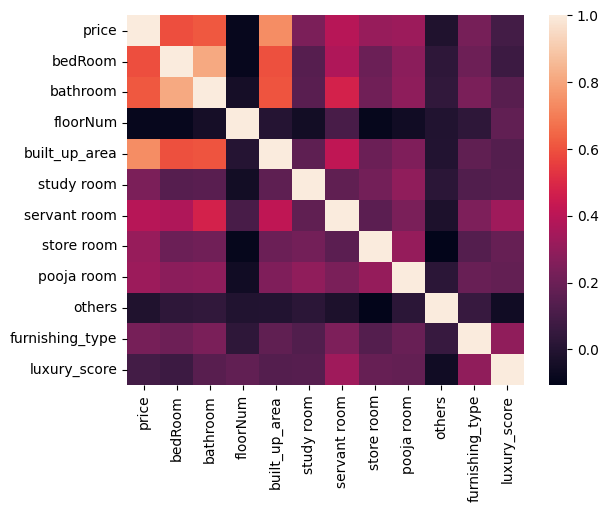

In [59]:
sns.heatmap(train_df.corr(numeric_only=True))

In [60]:
train_df.corr(numeric_only=True)['price'].sort_values(ascending=False)

price              1.000000
built_up_area      0.740396
bathroom           0.611955
bedRoom            0.592113
servant room       0.391925
pooja room         0.322168
store room         0.309149
study room         0.241464
furnishing_type    0.226856
luxury_score       0.090854
others            -0.013579
floorNum          -0.087534
Name: price, dtype: float64

### cols in question

### numerical -> luxury_score, others, floorNum
### categorical -> property_type, sector, agePossession

### Luxury score 

<Axes: ylabel='luxury_score'>

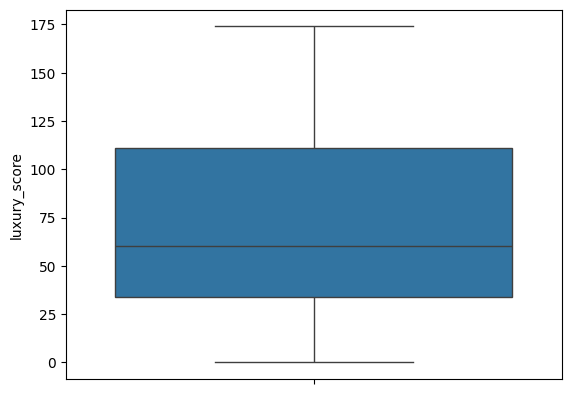

In [61]:
sns.boxplot(df['luxury_score'])

In [62]:
def categorize_luxury(score):
    if 0 <= score < 50:
        return "Low"
    elif 50 <= score < 150:
        return "Medium"
    elif 150 <= score <= 175:
        return "High"
    else:
        return None  # or "Undefined" or any other label for scores outside the defined bins

In [63]:
train_df['luxury_category'] = train_df['luxury_score'].apply(categorize_luxury)

In [64]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category
0,house,sector 92,0.85,4,4,3,4.0,Relatively New,1743.0,0,0,0,0,0,0,0,Low
1,flat,sector 92,1.08,4,4,2,16.0,New Property,1891.0,0,1,0,0,0,0,107,Medium
2,house,sector 33,8.00,4,4,3+,2.0,Old Property,7000.0,1,1,1,1,0,0,77,Medium
3,flat,sector 67a,1.60,3,3,2,3.0,New Property,1346.0,0,0,1,0,0,1,142,Medium
4,house,sector 46,4.50,6,6,3+,3.0,Moderately Old,1845.0,0,0,1,0,0,1,80,Medium


### floorNum

<Axes: ylabel='floorNum'>

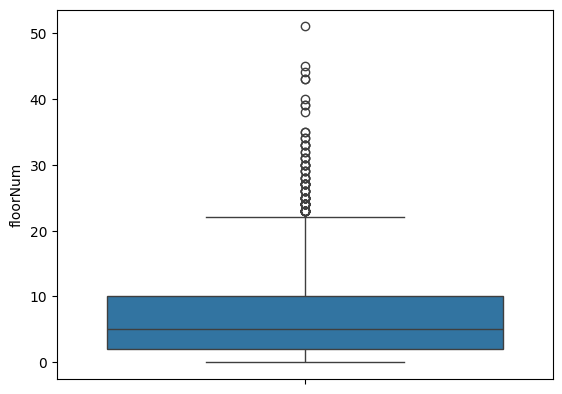

In [65]:
sns.boxplot(train_df['floorNum'])

In [66]:
def categorize_floor(floor):
    if 0 <= floor <= 2:
        return "Low Floor"
    elif 3 <= floor <= 10:
        return "Mid Floor"
    elif 11 <= floor <= 51:
        return "High Floor"
    else:
        return None  # or "Undefined" or any other label for floors outside the defined bins

In [67]:
train_df['floor_category'] = train_df['floorNum'].apply(categorize_floor)

In [68]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category,floor_category
0,house,sector 92,0.85,4,4,3,4.0,Relatively New,1743.0,0,0,0,0,0,0,0,Low,Mid Floor
1,flat,sector 92,1.08,4,4,2,16.0,New Property,1891.0,0,1,0,0,0,0,107,Medium,High Floor
2,house,sector 33,8.00,4,4,3+,2.0,Old Property,7000.0,1,1,1,1,0,0,77,Medium,Low Floor
3,flat,sector 67a,1.60,3,3,2,3.0,New Property,1346.0,0,0,1,0,0,1,142,Medium,Mid Floor
4,house,sector 46,4.50,6,6,3+,3.0,Moderately Old,1845.0,0,0,1,0,0,1,80,Medium,Mid Floor


In [69]:
train_df.drop(columns=['floorNum','luxury_score'],inplace=True)

In [70]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,house,sector 92,0.85,4,4,3,Relatively New,1743.0,0,0,0,0,0,0,Low,Mid Floor
1,flat,sector 92,1.08,4,4,2,New Property,1891.0,0,1,0,0,0,0,Medium,High Floor
2,house,sector 33,8.00,4,4,3+,Old Property,7000.0,1,1,1,1,0,0,Medium,Low Floor
3,flat,sector 67a,1.60,3,3,2,New Property,1346.0,0,0,1,0,0,1,Medium,Mid Floor
4,house,sector 46,4.50,6,6,3+,Moderately Old,1845.0,0,0,1,0,0,1,Medium,Mid Floor


In [71]:
before_encoding = train_df.copy(deep=True)
type(before_encoding)

pandas.core.frame.DataFrame

In [72]:
from sklearn.preprocessing import OrdinalEncoder

# Create a copy of the original data for label encoding
data_label_encoded = train_df.copy()

categorical_cols = train_df.select_dtypes(include=['object']).columns

# Apply label encoding to categorical columns
for col in categorical_cols:
    oe = OrdinalEncoder()
    data_label_encoded[col] = oe.fit_transform(data_label_encoded[[col]])
    print(oe.categories_)

# Splitting the dataset into training and testing sets
X_label = data_label_encoded.drop('price', axis=1)
y_label = data_label_encoded['price']

[array(['flat', 'house'], dtype=object)]
[array(['dwarka expressway', 'gwal pahari', 'manesar', 'sector 1',
       'sector 102', 'sector 103', 'sector 104', 'sector 105',
       'sector 106', 'sector 107', 'sector 108', 'sector 109',
       'sector 10a', 'sector 11', 'sector 110', 'sector 111',
       'sector 112', 'sector 113', 'sector 12', 'sector 13', 'sector 14',
       'sector 15', 'sector 17', 'sector 17a', 'sector 17b', 'sector 2',
       'sector 21', 'sector 22', 'sector 23', 'sector 24', 'sector 25',
       'sector 26', 'sector 27', 'sector 28', 'sector 3',
       'sector 3 phase 2', 'sector 3 phase 3 extension', 'sector 30',
       'sector 31', 'sector 33', 'sector 36', 'sector 36a', 'sector 37',
       'sector 37c', 'sector 37d', 'sector 38', 'sector 39', 'sector 4',
       'sector 40', 'sector 41', 'sector 43', 'sector 45', 'sector 46',
       'sector 47', 'sector 48', 'sector 49', 'sector 5', 'sector 50',
       'sector 51', 'sector 52', 'sector 53', 'sector 54', 'sector 5

In [73]:
X_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,1.0,105.0,4,4,3.0,3.0,1743.0,0,0,0,0,0,0,1.0,2.0
1,0.0,105.0,4,4,2.0,1.0,1891.0,0,1,0,0,0,0,2.0,0.0
2,1.0,39.0,4,4,4.0,2.0,7000.0,1,1,1,1,0,0,2.0,1.0
3,0.0,76.0,3,3,2.0,1.0,1346.0,0,0,1,0,0,1,2.0,2.0
4,1.0,52.0,6,6,4.0,0.0,1845.0,0,0,1,0,0,1,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3548,0.0,75.0,3,4,3.0,3.0,2123.0,0,1,0,0,0,1,2.0,0.0
3549,0.0,80.0,3,5,3.0,3.0,2167.0,0,1,0,0,0,0,0.0,2.0
3550,0.0,25.0,2,2,3.0,0.0,1281.0,0,0,0,0,0,0,2.0,1.0
3551,0.0,63.0,3,3,4.0,2.0,1800.0,0,1,0,1,1,0,0.0,2.0


In [74]:
y_label

0       0.85
1       1.08
2       8.00
3       1.60
4       4.50
        ... 
3548    3.40
3549    1.60
3550    0.98
3551    1.55
3552    7.52
Name: price, Length: 3553, dtype: float64

### Technique 1 - Correlation Analysis

<Axes: >

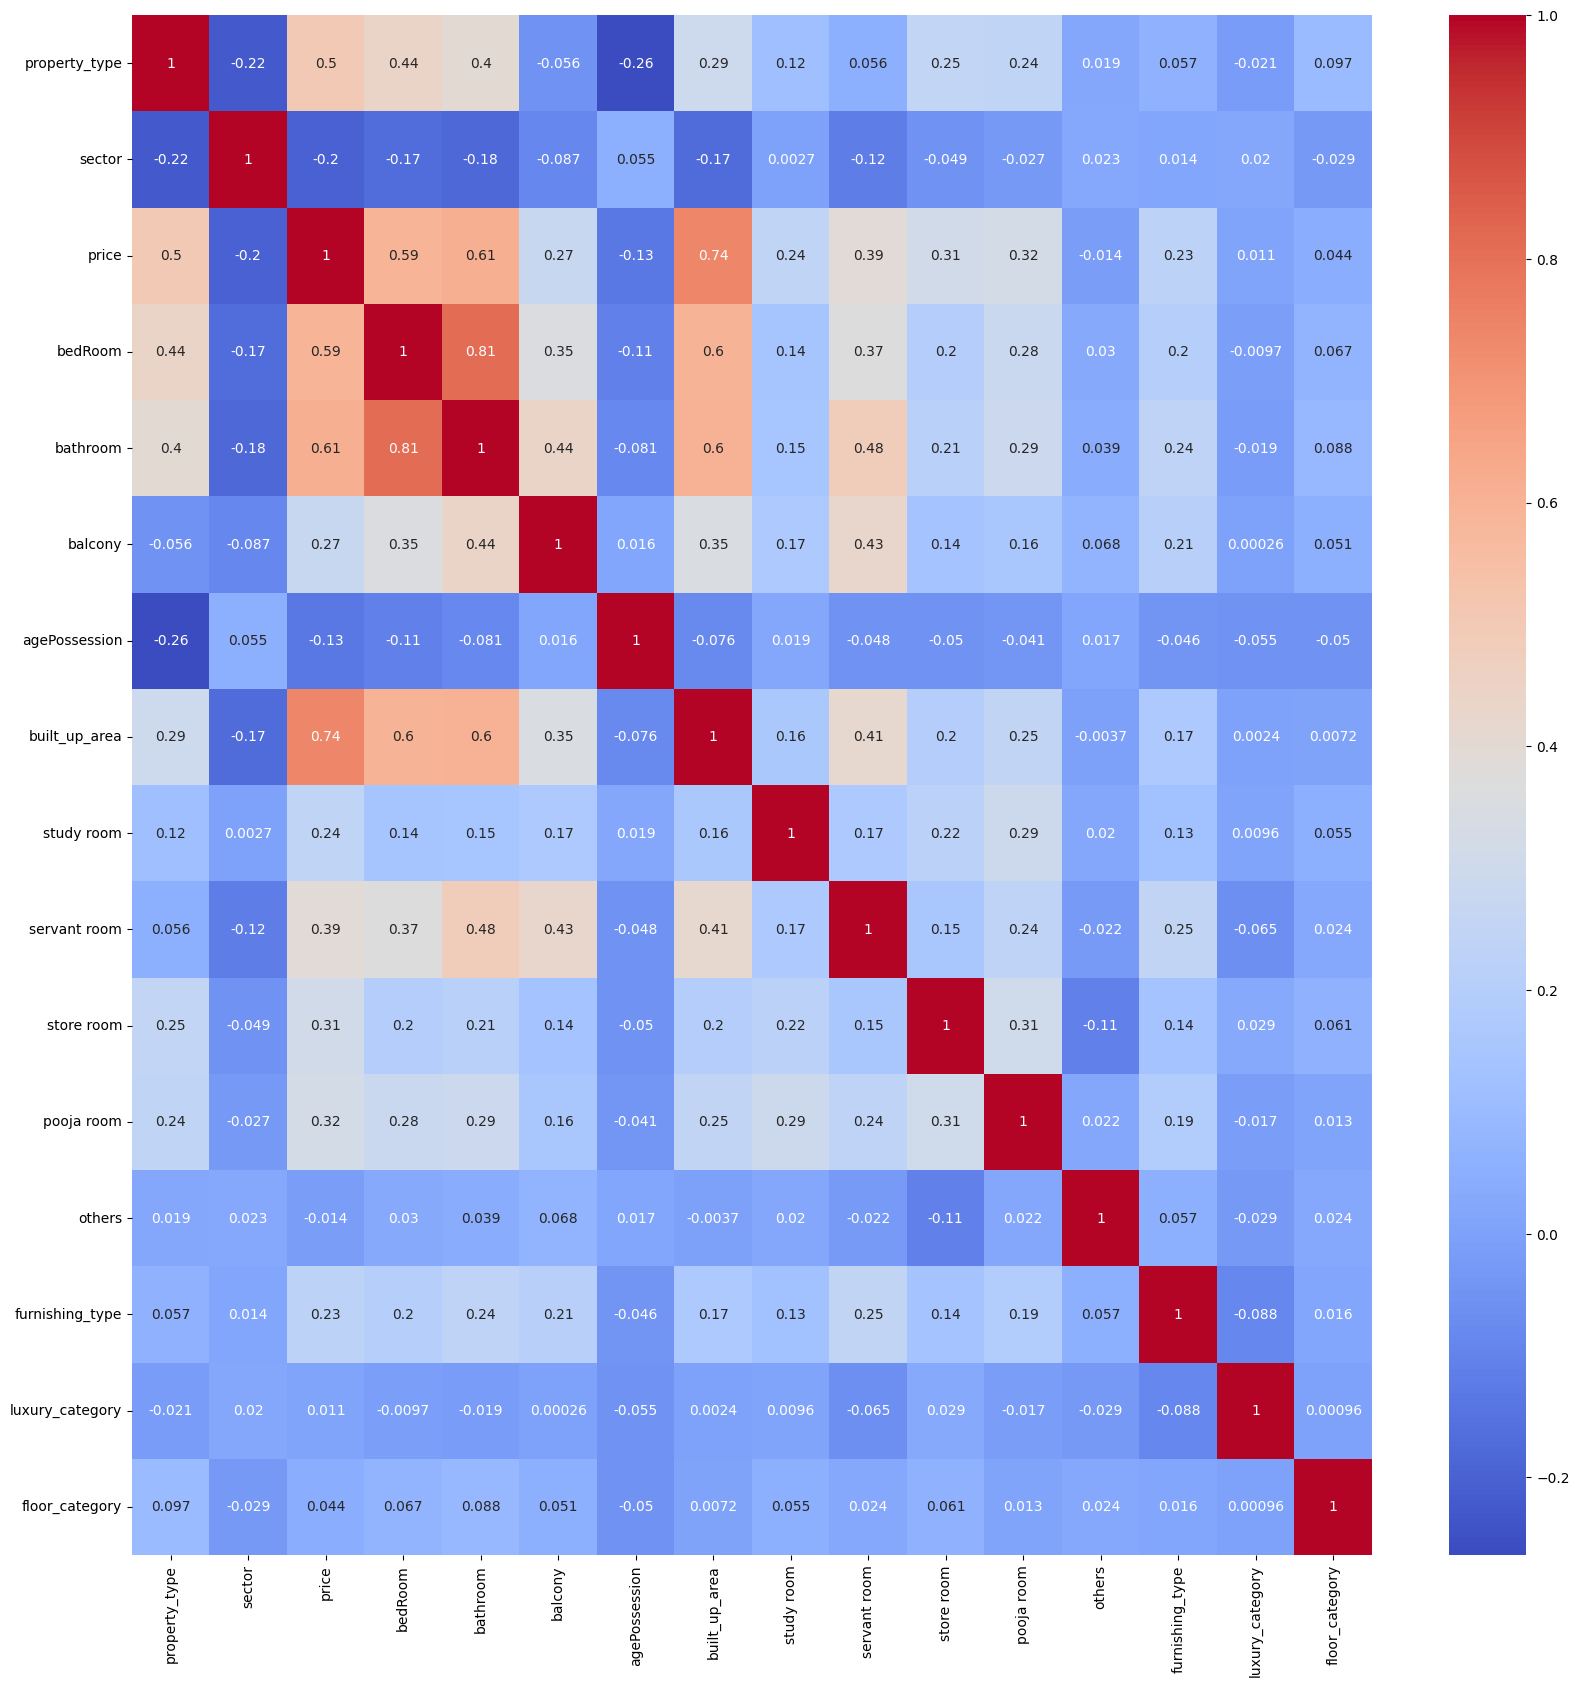

In [75]:
plt.figure(figsize=(20,20))
sns.heatmap(data_label_encoded.corr(), annot=True, cmap='coolwarm')

In [76]:
#data_label_encoded.drop(columns='property_type',inplace=True)
fi_df1 = (
    data_label_encoded.corr(numeric_only=True)['price']
      .sort_values(ascending=False)
      .reset_index()
)

fi_df1.columns = ['feature', 'Correlation_with_Price']

fi_df1

,feature,Correlation_with_Price
0,price,1.000000
1,built_up_area,0.740396
2,bathroom,0.611955
3,bedRoom,0.592113
4,property_type,0.503844
5,servant room,0.391925
6,pooja room,0.322168
7,store room,0.309149
8,balcony,0.269960
9,study room,0.241464


### Technique 2 - Random Forest Feature Importance

In [77]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X_label,y_label)
fi_df2 = (
    pd.DataFrame({
        'feature': X_label.columns,
        'rf_importance': rf.feature_importances_
    })
    .sort_values(by='rf_importance', ascending=False)
    .reset_index(drop=True)
)

fi_df2

,feature,rf_importance
0,built_up_area,0.646106
1,sector,0.101903
2,property_type,0.099729
3,bedRoom,0.031681
4,bathroom,0.023478
5,servant room,0.019921
6,agePossession,0.014337
7,balcony,0.013001
8,furnishing_type,0.010056
9,luxury_category,0.008411


In [78]:
from sklearn.ensemble import GradientBoostingRegressor
gb=GradientBoostingRegressor(n_estimators=100,random_state=42)
gb.fit(X_label,y_label)
# Extract feature importance scores for label encoded data
fi_df3 = pd.DataFrame({
    'feature': X_label.columns,
    'gb_importance': gb.feature_importances_
}).sort_values(by='gb_importance', ascending=False)

fi_df3

,feature,gb_importance
6,built_up_area,0.679276
1,sector,0.103702
0,property_type,0.094097
2,bedRoom,0.037073
3,bathroom,0.035502
8,servant room,0.027190
9,store room,0.008509
5,agePossession,0.005303
7,study room,0.003326
12,furnishing_type,0.002517


### Technique 4 - Permutation Importance

In [79]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_train_label, X_test_label, y_train_label, y_test_label = train_test_split(X_label, y_label, test_size=0.2, random_state=42)

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_train_label, y_train_label)

# Calculate Permutation Importance
perm_importance = permutation_importance(rf_label, X_test_label, y_test_label, n_repeats=30, random_state=42)

# Organize results into a DataFrame
fi_df4 = pd.DataFrame({
    'feature': X_label.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by='permutation_importance', ascending=False)

fi_df4

,feature,permutation_importance
6,built_up_area,0.735260
0,property_type,0.180544
1,sector,0.127708
8,servant room,0.025705
9,store room,0.007553
10,pooja room,0.006619
7,study room,0.002287
4,balcony,0.002139
13,luxury_category,0.001230
3,bathroom,0.000784


In [80]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

# Train a LASSO regression model
# We'll use a relatively small value for alpha (the regularization strength) for demonstration purposes
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled, y_label)

# Extract coefficients
fi_df5 = pd.DataFrame({
    'feature': X_label.columns,
    'lasso_coeff': lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

fi_df5

,feature,lasso_coeff
6,built_up_area,1.461572
0,property_type,0.710128
3,bathroom,0.295176
9,store room,0.201560
7,study room,0.176400
8,servant room,0.172754
12,furnishing_type,0.168087
10,pooja room,0.078427
13,luxury_category,0.058361
2,bedRoom,0.039364


In [81]:
from sklearn.feature_selection import RFE

# Initialize the base estimator
estimator = RandomForestRegressor()

# Apply RFE on the label-encoded and standardized training data
selector_label = RFE(estimator, n_features_to_select=X_label.shape[1], step=1)
selector_label = selector_label.fit(X_label, y_label)

# Get the selected features based on RFE
selected_features = X_label.columns[selector_label.support_]

# Extract the coefficients for the selected features from the underlying linear regression model
selected_coefficients = selector_label.estimator_.feature_importances_

# Organize the results into a DataFrame
fi_df6 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

fi_df6

,feature,rfe_score
6,built_up_area,0.649236
0,property_type,0.100858
1,sector,0.100515
2,bedRoom,0.027631
3,bathroom,0.024248
8,servant room,0.019672
5,agePossession,0.014070
4,balcony,0.012211
12,furnishing_type,0.010874
7,study room,0.009294


In [82]:
# Train a linear regression model on the label-encoded and standardized training data
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y_label)

# Extract coefficients
fi_df7 = pd.DataFrame({
    'feature': X_label.columns,
    'reg_coeffs': lin_reg.coef_
}).sort_values(by='reg_coeffs', ascending=False)

fi_df7

,feature,reg_coeffs
6,built_up_area,1.464162
0,property_type,0.708678
3,bathroom,0.302136
9,store room,0.206044
7,study room,0.184727
8,servant room,0.181659
12,furnishing_type,0.177345
10,pooja room,0.081475
13,luxury_category,0.069480
2,bedRoom,0.041953


In [83]:
#! pip install shap

In [84]:
import shap

# Compute SHAP values using the trained Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_label, y_label)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_label)

# Summing the absolute SHAP values across all samples to get an overall measure of feature importance
shap_sum = np.abs(shap_values).mean(axis=0)

shap_values

array([[ 7.32563092e-01, -1.29075639e+00,  1.06704495e-03, ...,
        -3.71956548e-02, -7.48406758e-03,  7.64419538e-03],
       [-3.57470403e-01, -8.17714127e-01, -8.70044356e-03, ...,
        -3.02082606e-02, -7.70131747e-03,  8.10067711e-03],
       [ 1.10495545e+00,  6.76391809e-02, -3.35584448e-01, ...,
        -5.93962696e-02,  1.85074555e-02,  3.83551416e-02],
       ...,
       [-2.34702955e-01,  2.81500046e-02, -6.69245211e-02, ...,
        -9.47188806e-03, -8.96805500e-03, -1.36913737e-02],
       [-3.91611856e-01,  1.89234131e-01, -3.80851086e-02, ...,
        -1.49702591e-02,  2.82876734e-02, -5.20165859e-02],
       [-4.52661812e-01,  1.04087333e+00,  1.28024297e-01, ...,
        -3.62200062e-02,  2.35561001e-02,  3.09886411e-02]],
      shape=(3553, 15))

In [85]:
fi_df8 = pd.DataFrame({
    'feature': X_label.columns,
    'SHAP_score': np.abs(shap_values).mean(axis=0)
}).sort_values(by='SHAP_score', ascending=False)

fi_df8

,feature,SHAP_score
6,built_up_area,1.244762
0,property_type,0.466366
1,sector,0.385215
3,bathroom,0.113105
8,servant room,0.095142
2,bedRoom,0.066716
4,balcony,0.040989
12,furnishing_type,0.026591
5,agePossession,0.025432
14,floor_category,0.023121


In [86]:
final_fi_df = fi_df1.merge(fi_df2,on='feature').merge(fi_df3,on='feature').merge(fi_df4,on='feature').merge(fi_df5,on='feature').merge(fi_df6,on='feature').merge(fi_df7,on='feature').merge(fi_df8,on='feature').set_index('feature')

In [87]:
final_fi_df

,Correlation_with_Price,rf_importance,gb_importance,permutation_importance,lasso_coeff,rfe_score,reg_coeffs,SHAP_score
feature,,,,,,,,
built_up_area,0.740396,0.646106,0.679276,0.735260,1.461572,0.649236,1.464162,1.244762
bathroom,0.611955,0.023478,0.035502,0.000784,0.295176,0.024248,0.302136,0.113105
bedRoom,0.592113,0.031681,0.037073,-0.011857,0.039364,0.027631,0.041953,0.066716
property_type,0.503844,0.099729,0.094097,0.180544,0.710128,0.100858,0.708678,0.466366
servant room,0.391925,0.019921,0.027190,0.025705,0.172754,0.019672,0.181659,0.095142
pooja room,0.322168,0.006159,0.000435,0.006619,0.078427,0.008026,0.081475,0.010853
store room,0.309149,0.007402,0.008509,0.007553,0.201560,0.006445,0.206044,0.017380
balcony,0.269960,0.013001,0.001046,0.002139,-0.031149,0.012211,-0.053953,0.040989
study room,0.241464,0.008217,0.003326,0.002287,0.176400,0.009294,0.184727,0.018356


In [88]:
# normalize the score
final_fi_df = final_fi_df.divide(final_fi_df.sum(axis=0), axis=1)

In [89]:
final_fi_df[['rf_importance','gb_importance','permutation_importance','rfe_score','SHAP_score']].mean(axis=1).sort_values(ascending=False)

feature
built_up_area      0.629366
property_type      0.129066
sector             0.115154
bathroom           0.025632
servant room       0.025587
bedRoom            0.022280
balcony            0.008854
agePossession      0.008461
store room         0.007239
study room         0.006029
furnishing_type    0.005844
luxury_category    0.005034
pooja room         0.005007
floor_category     0.004424
others             0.002024
dtype: float64

In [90]:
X_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,1.0,105.0,4,4,3.0,3.0,1743.0,0,0,0,0,0,0,1.0,2.0
1,0.0,105.0,4,4,2.0,1.0,1891.0,0,1,0,0,0,0,2.0,0.0
2,1.0,39.0,4,4,4.0,2.0,7000.0,1,1,1,1,0,0,2.0,1.0
3,0.0,76.0,3,3,2.0,1.0,1346.0,0,0,1,0,0,1,2.0,2.0
4,1.0,52.0,6,6,4.0,0.0,1845.0,0,0,1,0,0,1,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3548,0.0,75.0,3,4,3.0,3.0,2123.0,0,1,0,0,0,1,2.0,0.0
3549,0.0,80.0,3,5,3.0,3.0,2167.0,0,1,0,0,0,0,0.0,2.0
3550,0.0,25.0,2,2,3.0,0.0,1281.0,0,0,0,0,0,0,2.0,1.0
3551,0.0,63.0,3,3,4.0,2.0,1800.0,0,1,0,1,1,0,0.0,2.0


In [91]:
# with all the cols
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label, y_label, cv=5, scoring='r2')

In [92]:
scores.mean()

np.float64(0.8048392612981858)

In [93]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label.drop(columns=['pooja room', 'study room', 'others']), y_label, cv=5, scoring='r2')

In [94]:
scores.mean()

np.float64(0.8041966692128295)

In [95]:
export_df = X_label.drop(columns=['pooja room', 'study room', 'others'])
export_df['price'] = y_label

In [96]:
# Create the folder if it doesn't exist
os.makedirs("../data/feature_selection", exist_ok=True)

df.to_csv("../data/feature_selection/gurgaon_properties_post_feature_selection.csv", index=False)

print("Feature-selected dataset saved successfully!")

Feature-selected dataset saved successfully!


In [97]:
export_df

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category,price
0,1.0,105.0,4,4,3.0,3.0,1743.0,0,0,0,1.0,2.0,0.85
1,0.0,105.0,4,4,2.0,1.0,1891.0,1,0,0,2.0,0.0,1.08
2,1.0,39.0,4,4,4.0,2.0,7000.0,1,1,0,2.0,1.0,8.00
3,0.0,76.0,3,3,2.0,1.0,1346.0,0,1,1,2.0,2.0,1.60
4,1.0,52.0,6,6,4.0,0.0,1845.0,0,1,1,2.0,2.0,4.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3548,0.0,75.0,3,4,3.0,3.0,2123.0,1,0,1,2.0,0.0,3.40
3549,0.0,80.0,3,5,3.0,3.0,2167.0,1,0,0,0.0,2.0,1.60
3550,0.0,25.0,2,2,3.0,0.0,1281.0,0,0,0,2.0,1.0,0.98
3551,0.0,63.0,3,3,4.0,2.0,1800.0,1,0,0,0.0,2.0,1.55


In [98]:
before_encoding.shape

(3553, 16)

In [99]:
before_encoding=before_encoding.drop(columns=['pooja room', 'study room', 'others'])   


In [100]:
before_encoding.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category
0,house,sector 92,0.85,4,4,3,Relatively New,1743.0,0,0,0,Low,Mid Floor
1,flat,sector 92,1.08,4,4,2,New Property,1891.0,1,0,0,Medium,High Floor
2,house,sector 33,8.00,4,4,3+,Old Property,7000.0,1,1,0,Medium,Low Floor
3,flat,sector 67a,1.60,3,3,2,New Property,1346.0,0,1,1,Medium,Mid Floor
4,house,sector 46,4.50,6,6,3+,Moderately Old,1845.0,0,1,1,Medium,Mid Floor


In [101]:
# Create the folder if it doesn't exist
os.makedirs("../data/feature_selection", exist_ok=True)

before_encoding.to_csv("../data/feature_selection/gurgaon_properties_post_feature_selection_v2.csv", index=False)

print("Feature-selected with out encoding dataset saved successfully!")

Feature-selected with out encoding dataset saved successfully!
